📝 Giacomo Frisoni, Gianluca Moro

*{giacomo.frisoni, gianluca.moro}@unibo.it*

## 📜 Outline

- [ 1 - Hands-on Graph Neural Networks](#1)
  - [ 1.1 - Set Up](#1.1)
  - [ 1.2 - Node Classification](#1.2)
  - [ 1.3 - Link Prediction](#1.3)
  - [ 1.4 - Graph Prediction](#1.4)
- [ 2 - Hands-on Knowledge Graph Embedding](#2)
  - [ 2.1 - Set Up](#2.1)
  - [ 2.2 - KG Preparation](#2.2)
  - [ 1.3 - KGE with Random Entity Initialization](#2.3)
  - [ 1.4 - KGE with LM-Based Entity Initialization](#2.4)

</br>

**Note:** each section (1/2) can be run independently from the others. To ensure a clean environment for each sub-lab, you can disconnect and delete the runtime before starting a section.

<a name='1'></a>
# **Hands-on Graph Neural Networks**

Recently, deep learning on graphs has emerged to one of the hottest research fields in the deep learning community.
Here, **Graph Neural Networks (GNNs)** aim to generalize classical deep learning concepts to irregular structured data (in contrast to images or texts) and to enable neural networks to reason about objects and their relations.

This is done by following a simple **neural message passing scheme**, where node features $\mathbf{x}_v^{(\ell)}$ of all nodes $v \in \mathcal{V}$ in a graph $\mathcal{G} = (\mathcal{V}, \mathcal{E})$ are iteratively updated by aggregating localized information from their neighbors $\mathcal{N}(v)$:

$$
\mathbf{x}_v^{(\ell + 1)} = f^{(\ell + 1)}_{\theta} \left( \mathbf{x}_v^{(\ell)}, \left\{ \mathbf{x}_w^{(\ell)} : w \in \mathcal{N}(v) \right\} \right)
$$

GNNs have recently gained increasing popularity in both reseaerch and real-world applications, including domains such as social networks, bioinformatics, and recommender systems.

In this tutorial, you will learn how to construct your own GNNs, and how to use them to solve node-level, edge-level, and graph-level tasks.

You will use **[PyTorch Geometric (PyG)](https://github.com/rusty1s/pytorch_geometric)**, the most popular and easy-to-use GNN library.
Specifically, PyG is an extension library to the popular deep learning framework [PyTorch](https://pytorch.org/).

<img src="https://raw.githubusercontent.com/pyg-team/pyg_sphinx_theme/master/pyg_sphinx_theme/static/img/pyg_logo_text.svg?sanitize=true" alt="PyG logo" width="300"/>

FYK

| Framework | Primary Backend | Creator / Main Backer | Best Use Case |
| :--- | :--- | :--- | :--- |
| **PyG** | PyTorch | TU Dortmund / Kumo.AI | The "Default" choice; research & production. |
| **DGL** | PyTorch / TF / MXNet | AWS (Amazon) | High performance on giant graphs. |
| **Spektral** | TensorFlow (Keras) | Daniele Grattarola | Rapid prototyping with Keras API. |
| **Jraph** | JAX | Google DeepMind | TPU acceleration & functional programming. |

<a name='1.1'></a>
## ⚙️ Set Up Kernel, Required Dependencies, and Util Functions

Check that the Runtime type is `Python 3` with a `GPU`-based hardware accelerator.

Go to "Runtime" $→$ "Change runtime type".

### 📦 Packages

In [ ]:
import os
import time

# Check PyTorch version and install PyG accordingly
import torch
os.environ['TORCH'] = torch.__version__
print(torch.__version__)
!pip install -q torch-scatter -f https://data.pyg.org/whl/torch-${TORCH}.html
!pip install -q torch-sparse -f https://data.pyg.org/whl/torch-${TORCH}.html
!pip install -q git+https://github.com/pyg-team/pytorch_geometric.git

# Numerical operations
import numpy as np

# Network analysis and visualization
import networkx as nx

# Plotting
%matplotlib inline
import matplotlib.pyplot as plt
from matplotlib import animation
from mpl_toolkits.mplot3d import Axes3D
from IPython.display import HTML, Javascript

# Dimensionality reduction
from sklearn.manifold import TSNE

# Torch and PyG network design components
from torch.nn import Linear
from torch_geometric.nn import GCNConv, SAGEConv, to_hetero, global_mean_pool
import torch.nn.functional as F
from torch.utils.data import DataLoader

# PyG utils
from torch_geometric.utils import to_networkx, to_dense_adj
import torch_geometric.transforms as T

# PyG datasets
from torch_geometric.datasets import KarateClub, Planetoid, TUDataset
from torch_geometric.data import download_url, extract_zip, HeteroData
from torch_geometric.loader import LinkNeighborLoader, DataLoader

# Object-oriented support
from abc import ABC, abstractmethod
from dataclasses import dataclass

# Data structures for cleaner and safer code
from typing import Tuple, Optional, Dict, Any
from torch import Tensor

# Tabular data
import pandas as pd

# Progress bar
import tqdm

# Set global random seed for reproducibility
SEED = 42
torch.manual_seed(SEED)

2.8.0+cu126
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 51.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 38.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


### 📽️ Visual Utilities for Graph and Embedding Visualization

This cell provides reusable utility functions for visualizing graphs and node embeddings. All visual functions ensure that data reside on CPU.

In [ ]:
# ---------------------
# Constants
# ---------------------
FIGSIZE = (7, 7)
EMBED_COLOR_MAP = "Set2"
VIEW_ELEV = 30  # Elevation angle for 3D plots
VIEW_AZIM = 45  # Azimuthal angle for 3D plots

# ---------------------
# Max Output Cell Height Colab
# ---------------------
def limit_output_height(max_height=300):
    display(Javascript(f'''
        google.colab.output.setIframeHeight(0, true, {{maxHeight: {max_height}}})
    '''))

# ---------------------
# Graph Visualization
# ---------------------
def visualize_graph(graph, node_colors):
    """
    Display a static 2D visualization of a graph using NetworkX.

    Args:
        graph (networkx.Graph): The input graph.
        node_colors (list or tensor): Node colors (e.g., class labels).
    """
    plt.figure(figsize=FIGSIZE)
    plt.xticks([])
    plt.yticks([])

    nx.draw_networkx(
        graph,
        pos=nx.spring_layout(graph, seed=SEED),
        with_labels=False,
        node_color=node_colors,
        cmap=EMBED_COLOR_MAP
    )
    plt.show()

# ---------------------
# 3D Embedding Visualization
# ---------------------
def visualize_3d_embeddings(embeddings, classes):
    """
    Plot a static 3D scatter plot of node embeddings.
    Consider the first three dimensions of provided embeddings.

    Args:
        embeddings (torch.Tensor): Tensor of shape [num_nodes, embedding_dim].
        classes (torch.Tensor or list): Class labels for coloring nodes.
    """
    fig = plt.figure(figsize=FIGSIZE)
    ax = fig.add_subplot(111, projection='3d')

    h = embeddings.detach().cpu().numpy()
    c_np = classes.detach().cpu().numpy()

    ax.scatter(
        h[:, 0], h[:, 1], h[:, 2],
        s=140, c=c_np, cmap=EMBED_COLOR_MAP
    )

    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_zticks([])
    ax.view_init(elev=VIEW_ELEV, azim=VIEW_AZIM)

    plt.show()

# ---------------------
# 3D Embedding Animation
# ---------------------
def visualize_3d_embeddings_training(embeddings, classes, epochs=None, losses=None):
    """
    Animate 3D embeddings over training epochs.
    Consider the first three dimensions of provided embeddings.

    Args:
        embeddings (List[torch.Tensor]): List of embedding tensors per epoch.
        classes (torch.Tensor or list): Class labels for coloring nodes.
        epochs (List[int], optional): Epoch numbers corresponding to embeddings.
        losses (List[float], optional): Loss values per epoch.

    Returns:
        IPython.display.HTML: HTML5 animation of embeddings over time.
    """
    fig = plt.figure(figsize=FIGSIZE)
    ax = fig.add_subplot(111, projection='3d')

    c_np = classes.detach().cpu().numpy()

    def update(frame_idx):
        ax.clear()
        h = embeddings[frame_idx].detach().cpu().numpy()

        scatter = ax.scatter(
            h[:, 0], h[:, 1], h[:, 2],
            s=140, c=c_np, cmap=EMBED_COLOR_MAP
        )

        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_zticks([])
        ax.view_init(elev=VIEW_ELEV, azim=VIEW_AZIM)

        # Add dynamic title
        title_parts = []
        if epochs:
            title_parts.append(f"Epoch: {epochs[frame_idx]}")
        if losses:
            title_parts.append(f"Loss: {losses[frame_idx]:.4f}")
        ax.set_title(", ".join(title_parts), fontsize=16)

        return scatter,

    # Sample fewer frames if necessary (e.g., limit to ~40 frames)
    num_frames = len(embeddings)
    step = max(1, num_frames // 40)
    frame_indices = list(range(0, num_frames, step))

    plt.rcParams["animation.bitrate"] = 3000
    anim = animation.FuncAnimation(
        fig, update, frames=frame_indices,
        interval=200, blit=True, repeat=True
    )

    plt.close(fig)
    return HTML(anim.to_html5_video())

# ---------------------
# 2D t-SNE Visualization
# ---------------------
def visualize_2d_embeddings_tsne(embeddings, classes):
    """
    Project high-dimensional embeddings to 2D using t-SNE and plot.

    Args:
        embeddings (torch.Tensor): Tensor of shape [num_nodes, embedding_dim].
        classes (torch.Tensor or list): Class labels for coloring nodes.
    """
    h = embeddings.detach().cpu().numpy()
    c_np = classes.detach().cpu().numpy()
    z = TSNE(n_components=2).fit_transform(h)

    plt.figure(figsize=FIGSIZE)
    plt.xticks([])
    plt.yticks([])

    plt.scatter(z[:, 0], z[:, 1], s=70, c=c_np, cmap=EMBED_COLOR_MAP)
    plt.show()

### 📊 Dataset Statistics

Utility functions to quickly inspect PyG datasets and individual graph objects.

In [ ]:
def print_dataset_stats(dataset):
    """Prints basic statistics about a PyTorch Geometric dataset."""
    print(f'Dataset: {dataset.__class__.__name__}')
    print('======================')
    print(f'Number of graphs: {len(dataset)}')
    print(f'Number of features: {dataset.num_features}')
    print(f'Number of classes: {dataset.num_classes}')
    print()


def print_graph_stats(data):
    """Prints detailed statistics about a PyTorch Geometric graph object."""
    print(data)
    print('==============================================================')
    print(f'Number of nodes: {data.num_nodes}')
    print(f'Number of edges: {data.num_edges}')
    print(f'Average node degree: {data.num_edges / data.num_nodes:.2f}')

    if hasattr(data, 'train_mask'):
        num_train_nodes = int(data.train_mask.sum())
        print(f'Number of training nodes: {num_train_nodes}')
        print(f'Training node label rate: {num_train_nodes / data.num_nodes:.2f}')
    else:
        print('No training mask available.')

    print(f'Has isolated nodes: {data.has_isolated_nodes()}')
    print(f'Has self-loops: {data.has_self_loops()}')
    print(f'Is undirected: {data.is_undirected()}')
    print()

### 🧩 Model Wrapper Interface

A standardized interface for wrapping different types of models (e.g., GNNs, MLPs) used in graph learning. This abstraction:

- Ensures consistent training and evaluation behavior
- Provides a unified `forward` method for prediction and embedding extraction
- Supports both edge-aware (e.g., GNNs) and edge-agnostic (e.g., MLPs) models

Useful for building modular training pipelines and reducing boilerplate.

In [ ]:
class ModelWrapper(ABC):
    """Abstract base class for model wrappers that standardize model interfaces."""

    def __init__(self, model):
        self.model = model

    @abstractmethod
    def forward(self, data) -> Tuple[torch.Tensor, Optional[torch.Tensor]]:
        """
        Forward pass through the model.

        Returns:
            Tuple[logits, embeddings]: Task predictions and optional embeddings
        """
        pass

    def train(self):
        self.model.train()

    def eval(self):
        self.model.eval()

    def state_dict(self):
        return self.model.state_dict()

    def load_state_dict(self, state_dict):
        self.model.load_state_dict(state_dict)

    def to(self, device: torch.device):
        self.model.to(device)

class GNNWrapper(ModelWrapper):
    """Wrapper for Graph Neural Network models."""

    def forward(self, data) -> Tuple[torch.Tensor, Optional[torch.Tensor]]:
        output = self.model(data.x, data.edge_index)
        if isinstance(output, tuple):
            return output  # (logits, embeddings)
        else:
            # Some models do not have a dedicated classification layer
            # In this cases, logits == embeddings
            return output, output

class MLPWrapper(ModelWrapper):
    """Wrapper for Multi-Layer Perceptron models that only use node features."""

    def forward(self, data) -> Tuple[torch.Tensor, Optional[torch.Tensor]]:
        output = self.model(data.x)
        return output, None

class HeteroGNNWrapper(ModelWrapper):
    """Wrapper for Heterogeneous Graph Neural Network models."""

    def forward(self, data: HeteroData) -> Tuple[torch.Tensor, Optional[torch.Tensor]]:
        output = self.model(data)
        return output, None

class GNNGraphWrapper(ModelWrapper):
    """Wrapper for Graph Neural Network models aimed at graph-level tasks with mini-batching."""

    def forward(self, data) -> Tuple[torch.Tensor, Optional[torch.Tensor]]:
        output = self.model(data.x, data.edge_index, data.batch)
        return output, None

### 🏋️‍♂️ Training and Evaluation Framework

This cell implements a modular training pipeline. It includes:

- **`TrainingConfig`**: A dataclass for controlling training behavior (epochs, logging, video output, etc.)
- **Core training utilities**: Functions for `train_step`, `evaluate`, and `infer`.
- **`TrainingLogger`**: Logs training progress and optionally records embeddings for animation.
- **`CheckpointManager`**: Tracks and restores the best model based on validation accuracy.
- **`train()`**: A high-level orchestrator that integrates all components for streamlined training.

In [ ]:
# ---------------------------
# Training Configuration
# ---------------------------
@dataclass
class TrainingConfig:
    """Configuration for training parameters."""
    epochs: int = 200
    eval_validation: bool = True
    select_best_model_on_validation: bool = False
    make_video: bool = False
    print_every_epochs: int = 10
    loss_mask: Optional[Tensor] = None

# ---------------------------
# Device Management
# ---------------------------
def setup_device() -> torch.device:
    if torch.cuda.is_available():
        device = torch.device('cuda')
    else:
        device = torch.device('cpu')
    return device

# ---------------------------
# Core Training and Evaluation Functions
# ---------------------------
def infer(model_wrapper: ModelWrapper, data) -> Tuple[torch.Tensor, Optional[torch.Tensor]]:
    """
    Performs inference with the model.

    Args:
        model_wrapper: Wrapped model with standardized interface
        data: Input data

    Returns:
        Tuple of (logits, embeddings)
    """
    # Move model and data to device
    device = setup_device()
    model_wrapper.to(device)
    data.to(device)

    model_wrapper.eval()
    with torch.no_grad(): # Disables automatic PyTorch gradient calculation to save memory during inference and speed up computations
        return model_wrapper.forward(data)

def train_step(model_wrapper: ModelWrapper,
               data,
               label_field,
               criterion,
               label_field_nested = None,
               loss_mask = None) -> Tuple[torch.Tensor, Optional[torch.Tensor]]:
    """
    Executes a single training step.

    Args:
        model_wrapper: Wrapped model with standardized interface
        data: Input data
        label_field: Input data field containing ground truth labels
        label_field_nested: Second-level input data field containing ground truth labels
        criterion: Loss function
        loss_mask: Boolean flags to denote items for which limit loss computation

    Returns:
        Tuple of (loss, embeddings)
    """
    model_wrapper.train()

    # Forward pass
    logits, embeddings = model_wrapper.forward(data)

    # Compute loss on training nodes
    y = data[label_field]
    if label_field_nested is not None:
        y = y[label_field_nested]
    if loss_mask is not None:
        loss = criterion(logits[loss_mask], y[loss_mask])
    else:
        loss = criterion(logits, y)

    # Backpropagation
    loss.backward()

    return loss, embeddings

def evaluate(model_wrapper: ModelWrapper, data, mask) -> float:
    """
    Evaluates model accuracy on specified nodes.

    Args:
        model_wrapper: Wrapped model with standardized interface
        data: Input data
        mask: Boolean mask for evaluation subset

    Returns:
        Accuracy as float
    """
    # Move model and data to device
    device = setup_device()
    model_wrapper.to(device)
    data.to(device)

    model_wrapper.eval()
    with torch.no_grad():
        logits, _ = model_wrapper.forward(data)
        # Get the predicted class with the highest logit
        pred = logits.argmax(dim=1)
        # Compare predictions to true labels
        correct = pred[mask] == data.y[mask]
        accuracy = int(correct.sum()) / int(mask.sum())
        return accuracy

class TrainingLogger:
    """Handles logging and animation tracking during training."""

    def __init__(self, config: TrainingConfig):
        self.config = config

        # For video generation only
        self.embeddings_log = []
        self.losses_log = []
        self.epochs_log = []

    def log_training_epoch(self, epoch: int, loss: torch.Tensor, val_acc: Optional[float],
                           embeddings: Optional[torch.Tensor]):
        """Log training epoch results for printing and animation."""

        # Print progress
        if epoch % self.config.print_every_epochs == 0:
            if val_acc is not None:
                print(f"Epoch: {epoch:03d}, Loss: {loss:.4f}, Val Acc: {val_acc:.4f}")
            else:
                print(f"Epoch: {epoch:03d}, Loss: {loss:.4f}")

        # Store for video generation
        if self.config.make_video and embeddings is not None:
            self.embeddings_log.append(embeddings.detach().clone())
            self.losses_log.append(loss.item())
            self.epochs_log.append(epoch)

    def generate_animation(self, data):
        """Generate animation if requested and data is available."""
        animation_html = None
        if self.config.make_video and self.embeddings_log:
            animation_html = visualize_3d_embeddings_training(
                embeddings=self.embeddings_log,
                classes=data.y,
                epochs=self.epochs_log,
                losses=self.losses_log
            )

        return animation_html

class CheckpointManager:
    """Handles model checkpointing and restoration based on validation performance."""

    def __init__(self, enabled: bool = True):
        self.enabled = enabled
        self.best_val_acc = 0.0
        self.best_model_state = None

    def update_best_model(self, val_acc: float, model_wrapper: ModelWrapper) -> bool:
        """
        Update best model checkpoint if validation accuracy improved.

        Returns:
            bool: True if model was updated, False otherwise
        """
        if not self.enabled:
            return False

        if val_acc > self.best_val_acc:
            self.best_val_acc = val_acc
            self.best_model_state = model_wrapper.state_dict().copy()  # Deep copy for safety
            return True
        return False

    def restore_best_model(self, model_wrapper: ModelWrapper):
        """Restore the best model checkpoint."""
        if self.enabled and self.best_model_state is not None:
            model_wrapper.load_state_dict(self.best_model_state)
            print(f"Restored best model (Val Acc: {self.best_val_acc:.4f})")
        elif self.enabled:
            print("No best model checkpoint available to restore")

def train(model_wrapper: ModelWrapper,
          data,
          label_field,
          criterion,
          optimizer,
          label_field_nested = None,
          config: Optional[TrainingConfig] = None,
          train_loader: Optional[DataLoader] = None) -> Tuple[ModelWrapper, Optional[Any]]:
    """
    Main training loop with clean separation of concerns.

    Args:
        model_wrapper: Wrapped model with standardized interface
        data: Graph data
        label_field: Input data field containing ground truth labels
        label_field_nested: Second-level input data field containing ground truth labels
        criterion: Loss function
        optimizer: PyTorch optimizer
        config: Training configuration

    Returns:
        Tuple of (trained_model_wrapper, optional_animation)
    """
    if config is None:
        config = TrainingConfig()

    # Move model and data to device
    device = setup_device()
    model_wrapper.to(device)
    data.to(device)

    # Validate configuration
    if not config.eval_validation and config.select_best_model_on_validation:
        print("[Warning] select_best_model_on_validation=True ignored because eval_validation=False.")
        config.select_best_model_on_validation = False

    # Initialize components
    logger = TrainingLogger(config)
    checkpoint_manager = CheckpointManager(enabled=config.select_best_model_on_validation)

    # Determine training mode
    use_data_loader = train_loader is not None
    if use_data_loader:
        print(f"Training with DataLoader: {len(train_loader)} batches per epoch")
    else:
        print("Training with full data (single-pass per epoch)")

    # Training loop
    for epoch in range(1, config.epochs + 1):

        # Training step
        if use_data_loader:
            batch_losses_log = []
            # Zero gradients at start of epoch
            optimizer.zero_grad()
            # Computer per-batch loss and embeddings
            for batch_data in tqdm.tqdm(train_loader, desc=f"Epoch {epoch}", leave=False):
                batch_data.to(device)
                batch_loss, _ = train_step(model_wrapper, batch_data, label_field, criterion, label_field_nested, config.loss_mask)
                batch_losses_log.append(batch_loss.item())
            # We turn off the possibility of visualizing videos
            # since we have many node embeddings (one set per batch)
            embeddings = None
            # Step optimizer after all batches
            optimizer.step()
            # Calculate average loss for logging
            loss = torch.tensor(sum(batch_losses_log) / len(batch_losses_log))
        else:
            # Zero gradients at start of epoch
            optimizer.zero_grad()
            # Train step with all data at once
            loss, embeddings = train_step(model_wrapper, data, label_field, criterion, label_field_nested, config.loss_mask)
            # Step optimizer
            optimizer.step()

        # Validation step
        val_acc = None
        if config.eval_validation:
            val_acc = evaluate(model_wrapper, data, data.val_mask)

            # Update checkpoint if validation accuracy improved
            if checkpoint_manager.update_best_model(val_acc, model_wrapper):
                pass  # Could add additional logging here if needed

        # Log results (separate from checkpointing)
        logger.log_training_epoch(epoch, loss, val_acc, embeddings)

    # Restore best model if checkpointing was enabled
    checkpoint_manager.restore_best_model(model_wrapper)

    # Generate animation
    animation_html = logger.generate_animation(data)

    return model_wrapper, animation_html

<a name='1.2'></a>
## 1️⃣ Node Classification

### 🥋 Zachary's Karate Club

#### The Dataset & Task
We begin our journey into GNNs with the canonical "Hello World" dataset of graph learning: [**Zachary's Karate Club Network**](https://en.wikipedia.org/wiki/Zachary%27s_karate_club).

* **Graph Structure:** A social network consisting of **34 nodes** (club members) and **156 edges** (mutual friendships outside the club).
* **The Task:** **Node Classification** (specifically, Community Detection). Indeed, we must predict which of the **4 distinct communities** (classes) each member belongs to, based solely on the graph structure (who their friends are).

#### The Backstory
This dataset is not a computer simulation; it is the product of intense manual fieldwork by anthropologist **Wayne Zachary**. From 1970 to 1972, Zachary attended the club's events, parties, and meetings.

He recorded the data with strict criteria: he only drew an edge between two members if they interacted socially **outside** of the karate context (e.g., going to a bar or visiting each other's homes). Training together in the dojo did not count as a friendship edge.

#### The Conflict: Mr. Hi vs. The Officer
During the study, a massive political conflict erupted between the club's two leaders:
1.  **"Mr. Hi"** (The Karate Instructor)
2.  **"The Officer"** (The Club President/Administrator)

The dispute became so toxic that the club eventually split into two rival dojos. Historically, members had to choose a side, resulting in **2 factions**.

#### Why 4 Classes instead of 2?
While the real-life event had 2 outcomes, predicting a binary split is often too easy for modern AI. To make the task challenging, this dataset (as formalized by [Kipf et al. (2017)](https://arxiv.org/abs/1609.02907)) treats it as a **4-class problem**.

Using modularity clustering, the two main factions are further divided into sub-groups:
* **Core Supporters:** Members deeply embedded in the faction (close friends of the leaders).
* **Peripheral Supporters:** Members on the fringe of the faction (acquaintances).

By predicting these **4 classes** instead of just the 2 factions, we test the GNN's ability to understand fine-grained social density (cliques) rather than just a simple global divide.

#### Data

PyTorch Geometric provides an easy access to this dataset via the [`torch_geometric.datasets`](https://pytorch-geometric.readthedocs.io/en/latest/modules/datasets.html#torch_geometric.datasets) subpackage:

In [ ]:
dataset = KarateClub()
print_dataset_stats(dataset)

Dataset: KarateClub
Number of graphs: 1
Number of features: 34
Number of classes: 4



After initializing the [`KarateClub`](https://pytorch-geometric.readthedocs.io/en/latest/modules/datasets.html#torch_geometric.datasets.KarateClub) dataset, we first can inspect some of its properties.
For example, we can see that this dataset holds exactly **one graph**, and that each node in this dataset is assigned a **34-dimensional feature vector** (i.e., one-hot ID which uniquely describes the members of the karate club).
Furthermore, the graph holds exactly **4 classes**, which represent the community each node belongs to.

**👁️ Let's now look at the underlying graph in more detail.**

In [ ]:
data = dataset[0]  # Get the first graph object
print_graph_stats(data)

Data(x=[34, 34], edge_index=[2, 156], y=[34], train_mask=[34])
Number of nodes: 34
Number of edges: 156
Average node degree: 4.59
Number of training nodes: 4
Training node label rate: 0.12
Has isolated nodes: False
Has self-loops: False
Is undirected: True



Each graph in PyTorch Geometric is represented by a single [`Data`](https://pytorch-geometric.readthedocs.io/en/latest/modules/data.html#torch_geometric.data.Data) object.

We can see that this `data` object holds 4 attributes:
1. PyG refers to **node features** as `x` (each of the 34 nodes is assigned a 34-dim feature vector).
2. The `edge_index` property holds the information about the **graph
connectivity**, *i.e.*, a tuple of source and destination node indices for each edge.
3. PyG refers to **node labels** as `y` (each node is assigned to exactly one class).
4. There also exists an additional attribute called `train_mask`, which describes for which nodes we already know their community assigments. In other words, it is an optional attribute that tells which nodes should be used for training with a list of True or False statements.

The `data` object also provides some **utilities** to infer basic properties of the underlying graph.
For example, we can easily infer whether there exists isolated nodes in the graph (*i.e.* there exists no edge to any node), whether the graph contains self-loops (*i.e.*, $(v, v) \in \mathcal{E}$), or whether the graph is undirected (*i.e.*, for each edge $(v, w) \in \mathcal{E}$ there also exists the edge $(w, v) \in \mathcal{E}$).

**(1) Node features**

In [ ]:
print(f'x = {data.x.shape}')
print(data.x)

x = torch.Size([34, 34])
tensor([[1., 0., 0.,  ..., 0., 0., 0.],
        [0., 1., 0.,  ..., 0., 0., 0.],
        [0., 0., 1.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 1., 0., 0.],
        [0., 0., 0.,  ..., 0., 1., 0.],
        [0., 0., 0.,  ..., 0., 0., 1.]])


> Here, the node feature matrix `x` is an identity matrix: it does not contain any relevant information about the nodes. It could contain information like age, skill level, etc. but this is not the case in this dataset. It means we will have to classify our nodes just by looking at their connections.


**(2) Graph connectivity**

In [ ]:
limit_output_height()

print(f'edge_index = {data.edge_index.shape}')
print(data.edge_index.t())

<IPython.core.display.Javascript object>

edge_index = torch.Size([2, 156])
tensor([[ 0,  1],
        [ 0,  2],
        [ 0,  3],
        [ 0,  4],
        [ 0,  5],
        [ 0,  6],
        [ 0,  7],
        [ 0,  8],
        [ 0, 10],
        [ 0, 11],
        [ 0, 12],
        [ 0, 13],
        [ 0, 17],
        [ 0, 19],
        [ 0, 21],
        [ 0, 31],
        [ 1,  0],
        [ 1,  2],
        [ 1,  3],
        [ 1,  7],
        [ 1, 13],
        [ 1, 17],
        [ 1, 19],
        [ 1, 21],
        [ 1, 30],
        [ 2,  0],
        [ 2,  1],
        [ 2,  3],
        [ 2,  7],
        [ 2,  8],
        [ 2,  9],
        [ 2, 13],
        [ 2, 27],
        [ 2, 28],
        [ 2, 32],
        [ 3,  0],
        [ 3,  1],
        [ 3,  2],
        [ 3,  7],
        [ 3, 12],
        [ 3, 13],
        [ 4,  0],
        [ 4,  6],
        [ 4, 10],
        [ 5,  0],
        [ 5,  6],
        [ 5, 10],
        [ 5, 16],
        [ 6,  0],
        [ 6,  4],
        [ 6,  5],
        [ 6, 16],
        [ 7,  0],
        [ 7,

> `edge_index` is a `[2, num_edges]` tensor that defines the connections between nodes in the graph. Each column $[i, j]$ means there is a directed edge from node $i$ to node $j$. This memory-efficient representation is also called **coordinate format (COO)**. So, instead of holding the adjacency information in a dense representation $\mathbf{A} \in \{ 0, 1 \}^{|\mathcal{V}| \times |\mathcal{V}|}$, PyG represents graphs sparsely, which refers to only holding the coordinates/values for which entries in $\mathbf{A}$ are non-zero. Importantly, PyG does not distinguish between directed and undirected graphs, and treats undirected graphs as a special case of directed graphs in which reverse edges exist for every entry in `edge_index`.

> Note that the adjacency matrix can be inferred from the `edge_index` with an utility function.

In [ ]:
A = to_dense_adj(data.edge_index)[0].numpy().astype(int)
print(f'A = {A.shape}')
print(A)

A = (34, 34)
[[0 1 1 ... 1 0 0]
 [1 0 1 ... 0 0 0]
 [1 1 0 ... 0 1 0]
 ...
 [1 0 0 ... 0 1 1]
 [0 0 1 ... 1 0 1]
 [0 0 0 ... 1 1 0]]


**(3) Ground-truth labels**

In [ ]:
print(f'y = {data.y.shape}')
print(data.y)

y = torch.Size([34])
tensor([1, 1, 1, 1, 3, 3, 3, 1, 0, 1, 3, 1, 1, 1, 0, 0, 3, 1, 0, 1, 0, 1, 0, 0,
        2, 2, 0, 0, 2, 0, 0, 2, 0, 0])


**(4) Train mask**

In [ ]:
print(f'train_mask = {data.train_mask.shape}')
print(data.train_mask)

train_mask = torch.Size([34])
tensor([ True, False, False, False,  True, False, False, False,  True, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False,  True, False, False, False, False, False,
        False, False, False, False])


> In total, we are only aware of the ground-truth labels of 4 nodes (one for each community), and the task is to infer the community assignment for the remaining nodes.

**Graph visualization**

We can convert a graph from PyG to the `networkx` library format, which implements, in addition to graph manipulation functionalities, powerful tools for visualization.

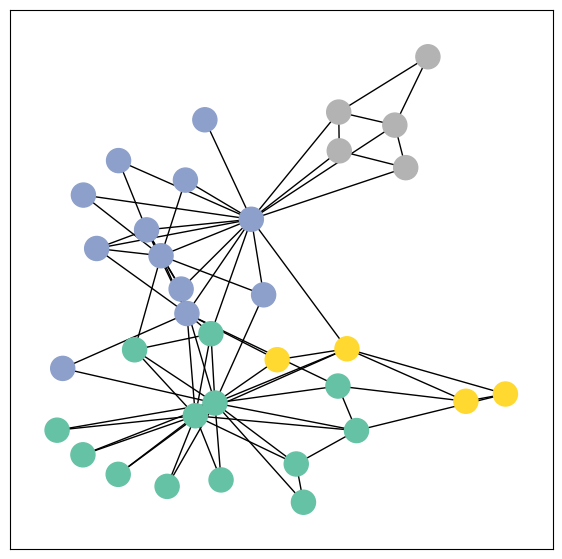

In [ ]:
G = to_networkx(data, to_undirected=True)
visualize_graph(G, data.y)

#### GCN Training

**After learning about PyG's data handling, it's time to implement our first GNN!**

For this, we will use one of the most simple GNN operators, the **GCN layer** ([Kipf et al. (2017)](https://arxiv.org/abs/1609.02907)), which is defined as

$$
\mathbf{x}_v^{(\ell + 1)} = \mathbf{W}^{(\ell + 1)} \sum_{w \in \mathcal{N}(v) \, \cup \, \{ v \}} \frac{1}{c_{w,v}} \cdot \mathbf{x}_w^{(\ell)}
$$

where $\mathbf{W}^{(\ell + 1)}$ denotes a trainable weight matrix of shape `[num_output_features, num_input_features]` and $c_{w,v}$ refers to a fixed normalization coefficient for each edge.

</br>

🔍 **Why Normalize at All? Which is the role of $c_{w,v}$?**

In standard neural networks like CNNs, each pixel has a fixed number of neighbors (e.g., 3x3 filters), so the aggregation process is uniform. But in graphs:

- Node A might have 1 neighbor
- Node B might have 500 neighbors

If we naïvely sum all neighboring features, Node B's embedding would explode in magnitude, making it hard to compare with Node A.

To make node embeddings comparable and numerically stable, we normalize by the number of neighbors.

$c_{w,v} = deg(w)$

Kipf et al. noticed an asymmetry: this mean version gives more "influence" to high-degree nodes. To fix this, they use symmetric normalization:

$c_{w,v} = \sqrt{deg(w)}\sqrt{deg(v)}$

</br>

🧱 **How to implement a GCN layer?**

PyG implements this layer via [`GCNConv`](https://pytorch-geometric.readthedocs.io/en/latest/modules/nn.html#torch_geometric.nn.conv.GCNConv), which can be executed by passing in the node feature representation `x` and the COO graph connectivity representation `edge_index`.

</br>

⛩️ **Architecture**

Here, we first initialize all of our building blocks in `__init__` and define the computation flow of our network in `forward`.
We first define and stack **3 GCN layers**, which corresponds to aggregating 3-hop neighborhood information around each node (all nodes up to 3 "hops" away).
In addition, the `GCNConv` layers progressively reduce the node feature dimensionality. Each `GCNConv` layer is enhanced by a [tanh](https://pytorch.org/docs/stable/generated/torch.nn.Tanh.html?highlight=tanh#torch.nn.Tanh) non-linearity.

After that, we apply a single **linear transformation** ([`torch.nn.Linear`](https://pytorch.org/docs/stable/generated/torch.nn.Linear.html?highlight=linear#torch.nn.Linear)) that acts as a classifier to map our nodes to 1 out of the 4 classes/communities.

We return both the output of the final classifier as well as the final node embeddings produced by our GNN.

In [ ]:
class GCN(torch.nn.Module):
    def __init__(
        self,
        num_features,
        h_dimensions_1,
        h_dimensions_2,
        h_dimensions_3,
        num_classes):
        super().__init__()
        self.conv1 = GCNConv(num_features, h_dimensions_1)
        self.conv2 = GCNConv(h_dimensions_1, h_dimensions_2)
        self.conv3 = GCNConv(h_dimensions_2, h_dimensions_3)
        self.classifier = Linear(h_dimensions_3, num_classes)

    def forward(self, x, edge_index):
        h = self.conv1(x, edge_index)
        h = h.tanh()
        h = self.conv2(h, edge_index)
        h = h.tanh()
        h = self.conv3(h, edge_index)
        h = h.tanh()  # Final GNN embedding space
        # h = the final node embeddings after the message passing layers

        # Apply a (linear) classifier
        out = self.classifier(h)
        # out = task-specific output (e.g., class logits for node classification)

        return out, h

We proceed to initialize our final model via `GCN()`, and printing all its sub-modules.

In [ ]:
model = GCN(dataset.num_features, 8, 4, 3, dataset.num_classes) # 34 (in) --> 8 --> 4 --> 3 --> 4 (out)
model = GNNWrapper(model)
print(model.model)

GCN(
  (conv1): GCNConv(34, 8)
  (conv2): GCNConv(8, 4)
  (conv3): GCNConv(4, 3)
  (classifier): Linear(in_features=3, out_features=4, bias=True)
)


👁️ Let's take a look at the node embeddings produced by our **untrained** GNN.

Embedding shape: [34, 3]


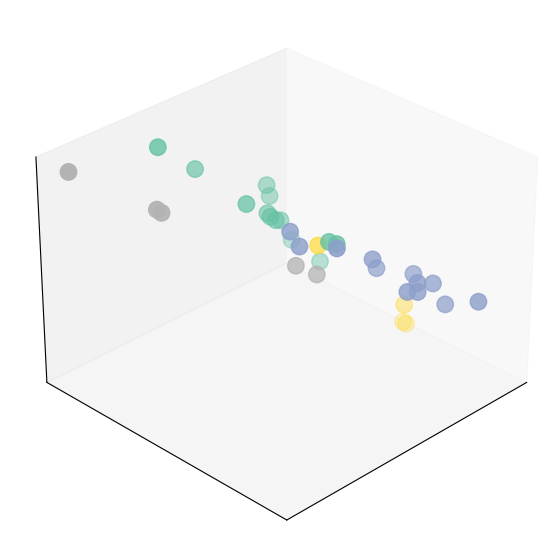

In [ ]:
_, embeddings = infer(model, data)
print(f'Embedding shape: {list(embeddings.shape)}')

visualize_3d_embeddings(embeddings.cpu(), classes=data.y.cpu())

🔥 **It is training time!**

Let's look at an example on how to train our network parameters based on the knowledge of the community assignments of 4 nodes in the graph.

Since everything in our model is differentiable and parameterized, we can add some labels, train the model and observe how the embeddings react.

Training our model is very similar to any other PyTorch model.
- In addition to defining our network architecture, we specify a loss criterion (here, [`CrossEntropyLoss`](https://pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html)) and initialize a stochastic gradient optimizer (here, [`Adam`](https://pytorch.org/docs/stable/optim.html?highlight=adam#torch.optim.Adam)).
- After that, we perform multiple rounds of optimization, where each round consists of a forward and backward pass to compute the gradients of our model parameters w.r.t. to the loss derived from the forward pass.

If you are not new to PyTorch, this scheme should appear familar to you.
Otherwise, the PyTorch docs provide [a good introduction on how to train a neural network in PyTorch](https://pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html#define-a-loss-function-and-optimizer).



Here, we make use of a **transductive learning procedure**.

**We are given the ground-truth labels of only a small subset of nodes, and want to infer the labels for all the remaining nodes**.
```
loss = criterion(out[data.train_mask], data.y[data.train_mask])
```
While we compute node embeddings for all of our nodes, we **only make use of the training nodes for computing the loss**.
In other words, we simply train against one node per class, but are allowed to make use of the complete input graph data.
Here, this is implemented by filtering the output of the classifier `out` and ground-truth labels `data.y` to only contain the nodes in the `train_mask`.

👁️ Let us now start training and **see how our node embeddings evolve over time**.

In [ ]:
limit_output_height()

criterion = torch.nn.CrossEntropyLoss()  # Define loss criterion
optimizer = torch.optim.Adam(model.model.parameters(), lr=0.01)  # Define optimizer

# Transformers/CNNs (Mini-Batch Training):
# - Imagine training on ImageNet (1,000,000 images) with a batch size of 32.
# - In one single epoch, the model updates its weights 31,250 times (1M / 32).
# - The model learns a lot in just one epoch because it sees thousands of gradient updates.
# ---
# GNNs on ZKC (Full-Batch Training):
# - Zachary's Karate Club is tiny (34 nodes). We usually feed the entire graph into the model at once.
# - This means one epoch = one single gradient update.
# - To get the same amount of "learning steps" that a Transformer gets in one epoch, a GNN on ZKC might need hundreds or thousands of epochs.

config = TrainingConfig(
    epochs=200,
    eval_validation=False,
    make_video=True,
    print_every_epochs=10,
    loss_mask=data.train_mask
)

model, animation_html = train(
    model_wrapper=model,
    data=data,
    label_field="y",
    label_field_nested=None,
    criterion=criterion,
    optimizer=optimizer,
    config=config
)

<IPython.core.display.Javascript object>

Training with full data (single-pass per epoch)
Epoch: 010, Loss: 1.3206
Epoch: 020, Loss: 1.1251
Epoch: 030, Loss: 0.8907
Epoch: 040, Loss: 0.7700
Epoch: 050, Loss: 0.7263
Epoch: 060, Loss: 0.7064
Epoch: 070, Loss: 0.6800
Epoch: 080, Loss: 0.6186
Epoch: 090, Loss: 0.5170
Epoch: 100, Loss: 0.3891
Epoch: 110, Loss: 0.2798
Epoch: 120, Loss: 0.2098
Epoch: 130, Loss: 0.1646
Epoch: 140, Loss: 0.1339
Epoch: 150, Loss: 0.1122
Epoch: 160, Loss: 0.0962
Epoch: 170, Loss: 0.0840
Epoch: 180, Loss: 0.0744
Epoch: 190, Loss: 0.0667
Epoch: 200, Loss: 0.0603


In [ ]:
display(animation_html)

As one can see, our 3-layer GCN model manages to linearly separating the communities and classifying most of the nodes correctly.

Furthermore, we did this all with a few lines of code, thanks to the PyG library which helped us out with data handling and GNN implementations.

### 📜 Cora

#### Data

In this section, we move to a more complex and real-world dataset.
We make use of the `Cora` dataset, which is a **citation network** where nodes represent documents.
- *Nodes.* Each document is described by a 1,433-dimensional bag-of-words feature vector.
- *Edges.* Two documents are connected if there exists a citation link between them.
- *Goal.* The task is to infer the category of each document (7 in total).

This dataset was first introduced by [Yang et al. (2016)](https://arxiv.org/abs/1603.08861) as one of the datasets of the `Planetoid` benchmark suite.
We again can make use of PyG for an easy access to this dataset via [`torch_geometric.datasets.Planetoid`](https://pytorch-geometric.readthedocs.io/en/latest/modules/datasets.html#torch_geometric.datasets.Planetoid).

In [ ]:
dataset = Planetoid(root='data/Planetoid', name='Cora', transform=T.NormalizeFeatures())
print_dataset_stats(dataset)

Dataset: Planetoid
Number of graphs: 1
Number of features: 1433
Number of classes: 7



Processing...
Done!


In [ ]:
data = dataset[0]
print_graph_stats(data)

Data(x=[2708, 1433], edge_index=[2, 10556], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708])
Number of nodes: 2708
Number of edges: 10556
Average node degree: 3.90
Number of training nodes: 140
Training node label rate: 0.05
Has isolated nodes: False
Has self-loops: False
Is undirected: True



Overall, this dataset is quite similar to the previously used [`KarateClub`](https://pytorch-geometric.readthedocs.io/en/latest/modules/datasets.html#torch_geometric.datasets.KarateClub) network.
We can see that the `Cora` network holds 2,708 nodes and 10,556 edges, with an average node degree of 3.9.
For training this dataset, we are given the ground-truth categories of 140 nodes (20 samples for each class).
This results in a training node label rate of only 5%.

In contrast to `KarateClub`, this graph holds the additional attributes `val_mask` and `test_mask`, denoting which nodes should be used for validation and testing.
Furthermore, we make use of **[data transformations](https://pytorch-geometric.readthedocs.io/en/latest/notes/introduction.html#data-transforms) via `transform=T.NormalizeFeatures()`**.
Transforms can be used to modify your input data before inputting them into a neural network, *e.g.*, for normalization or data augmentation.
Here, we [row-normalize](https://pytorch-geometric.readthedocs.io/en/latest/modules/transforms.html#torch_geometric.transforms.NormalizeFeatures) the bag-of-words input feature vectors.

We can further see that this network is undirected, and that there exists no isolated nodes (each document has at least one citation).

#### MLP Training and Evaluation

In theory, we should be able to infer the category of a document solely based on its content, *i.e.* its bag-of-words feature representation, without taking any relational information into account.

Let's verify that by constructing a simple MLP that solely operates on input node features (using shared weights across all nodes).

**Architecture**
- Our MLP is defined by two linear layers, enhanced by [ReLU](https://pytorch.org/docs/stable/generated/torch.nn.ReLU.html?highlight=relu#torch.nn.ReLU) non-linearity and [dropout](https://pytorch.org/docs/stable/generated/torch.nn.Dropout.html?highlight=dropout#torch.nn.Dropout).
- We first reduce the 1,433-dimensional feature vector to a low-dimensional embedding.
- The second linear layer acts as a classifier that should map each low-dimensional node embedding to one of the 7 classes.

In [ ]:
class MLP(torch.nn.Module):
    def __init__(self, hidden_channels):
        super().__init__()
        self.lin1 = Linear(dataset.num_features, hidden_channels)
        self.lin2 = Linear(hidden_channels, dataset.num_classes)

    def forward(self, x):
        x = self.lin1(x)
        x = x.relu()
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin2(x)
        return x

In [ ]:
model = MLP(hidden_channels=16)
model = MLPWrapper(model)
print(model.model)

MLP(
  (lin1): Linear(in_features=1433, out_features=16, bias=True)
  (lin2): Linear(in_features=16, out_features=7, bias=True)
)


Let's train our simple MLP by following a similar procedure as described in the first part of this tutorial.
We again make use of the **cross-entropy loss** and **Adam optimizer**.
This time, we also run evaluation on the test node set (which labels have not been observed during training).

In [ ]:
limit_output_height()

criterion = torch.nn.CrossEntropyLoss()  # Define loss criterion
optimizer = torch.optim.Adam(model.model.parameters(), lr=0.01, weight_decay=5e-4)  # Define optimizer

config = TrainingConfig(
    epochs=200,
    eval_validation=True,
    select_best_model_on_validation=True,
    make_video=False,
    print_every_epochs=10,
    loss_mask=data.train_mask
)

model, _ = train(
    model_wrapper=model,
    data=data,
    label_field="y",
    label_field_nested=None,
    criterion=criterion,
    optimizer=optimizer,
    config=config
)

evaluate(model, data, data.test_mask)

<IPython.core.display.Javascript object>

Training with full data (single-pass per epoch)
Epoch: 010, Loss: 1.9008, Val Acc: 0.1560
Epoch: 020, Loss: 1.7783, Val Acc: 0.3420
Epoch: 030, Loss: 1.5851, Val Acc: 0.3760
Epoch: 040, Loss: 1.3537, Val Acc: 0.4320
Epoch: 050, Loss: 1.1370, Val Acc: 0.4560
Epoch: 060, Loss: 0.9465, Val Acc: 0.4720
Epoch: 070, Loss: 0.7028, Val Acc: 0.4940
Epoch: 080, Loss: 0.6645, Val Acc: 0.5220
Epoch: 090, Loss: 0.5702, Val Acc: 0.5360
Epoch: 100, Loss: 0.5415, Val Acc: 0.5440
Epoch: 110, Loss: 0.5442, Val Acc: 0.5540
Epoch: 120, Loss: 0.5921, Val Acc: 0.5500
Epoch: 130, Loss: 0.4778, Val Acc: 0.5360
Epoch: 140, Loss: 0.4815, Val Acc: 0.5340
Epoch: 150, Loss: 0.4052, Val Acc: 0.5440
Epoch: 160, Loss: 0.4464, Val Acc: 0.5440
Epoch: 170, Loss: 0.4041, Val Acc: 0.5460
Epoch: 180, Loss: 0.4534, Val Acc: 0.5340
Epoch: 190, Loss: 0.3396, Val Acc: 0.5400
Epoch: 200, Loss: 0.4135, Val Acc: 0.5280
Restored best model (Val Acc: 0.5560)


0.554

💀 As one can see, our MLP performs rather bad with only about 56% test accuracy.

*But why does the MLP do not perform better?*
- The main reason for that is that this model suffers from **heavy overfitting** due to only having access to a small amount of training nodes, and therefore generalizes poorly to unseen node representations.
- It also **fails to incorporate an important bias into the model: cited papers are very likely related to the category of a document**. That is exactly where GNNs come into play and can help to boost the performance of our model.

#### GCN Training and Evaluation

We can easily convert our MLP to a GNN by swapping the `torch.nn.Linear` layers with PyG's GNN operators.

Following-up on the first part of this tutorial, we replace the linear layers by the [`GCNConv`](https://pytorch-geometric.readthedocs.io/en/latest/modules/nn.html#torch_geometric.nn.conv.GCNConv) module.

In contrast to a `GCNConv` layer, a single `Linear` layer is defined as

$$
\mathbf{x}_v^{(\ell + 1)} = \mathbf{W}^{(\ell + 1)} \mathbf{x}_v^{(\ell)}
$$

which does not make use of neighboring node information.

In [ ]:
from torch_geometric.nn import GCNConv

class GCN(torch.nn.Module):
    def __init__(self, num_features, h_dimensions, num_classes):
        super().__init__()
        self.conv1 = GCNConv(num_features, h_dimensions)
        self.conv2 = GCNConv(h_dimensions, num_classes)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.conv2(x, edge_index)
        return x

In [ ]:
model = GCN(dataset.num_features, 16, dataset.num_classes)
model = GNNWrapper(model)
print(model.model)

GCN(
  (conv1): GCNConv(1433, 16)
  (conv2): GCNConv(16, 7)
)


Let's visualize the node embeddings of our **untrained** GCN network.
For visualization, we make use of [**TSNE**](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html) to embed our 7-dimensional node embeddings onto a 2D plane.

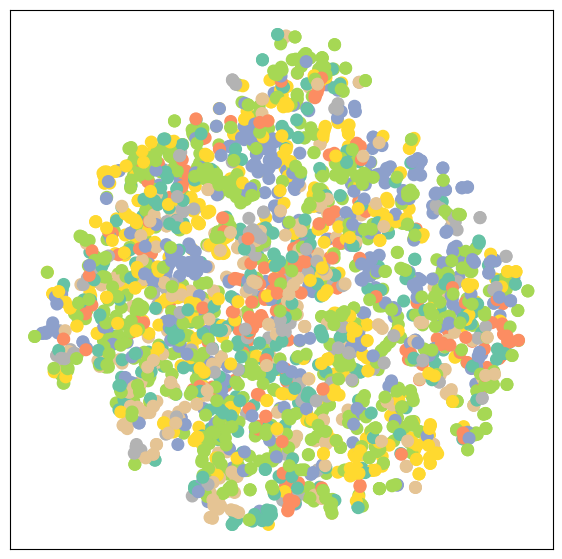

In [ ]:
_, embeddings = infer(model, data)
visualize_2d_embeddings_tsne(embeddings, data.y)

We certainly can do better by training our model.
The training and testing procedure is once again the same of MLP, but this time we make use of the node features `x` **and** the graph connectivity `edge_index` as input.

In [ ]:
limit_output_height()

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.model.parameters(), lr=0.01, weight_decay=5e-4)

config = TrainingConfig(
    epochs=100,
    eval_validation=True,
    select_best_model_on_validation=True,
    make_video=False,
    print_every_epochs=10,
    loss_mask=data.train_mask
)

model, _ = train(
    model_wrapper=model,
    data=data,
    label_field="y",
    label_field_nested=None,
    criterion=criterion,
    optimizer=optimizer,
    config=config
)

evaluate(model, data, data.test_mask)

<IPython.core.display.Javascript object>

Training with full data (single-pass per epoch)
Epoch: 010, Loss: 1.8808, Val Acc: 0.5960
Epoch: 020, Loss: 1.7320, Val Acc: 0.6640
Epoch: 030, Loss: 1.5668, Val Acc: 0.6680
Epoch: 040, Loss: 1.3361, Val Acc: 0.7200
Epoch: 050, Loss: 1.1309, Val Acc: 0.7240
Epoch: 060, Loss: 0.9645, Val Acc: 0.7560
Epoch: 070, Loss: 0.8351, Val Acc: 0.7660
Epoch: 080, Loss: 0.7009, Val Acc: 0.7780
Epoch: 090, Loss: 0.6340, Val Acc: 0.7920
Epoch: 100, Loss: 0.5390, Val Acc: 0.7900
Restored best model (Val Acc: 0.7980)


0.807

**There it is!**
By simply swapping the linear layers with GNN layers, we can reach **>81% of test accuracy**!
This is in stark contrast to the 56% of test accuracy obtained by our MLP, indicating that relational information plays a crucial role in obtaining better performance.

We can also verify that once again by looking at the output embeddings of our **trained** model, which now produces a far better clustering of nodes of the same category.

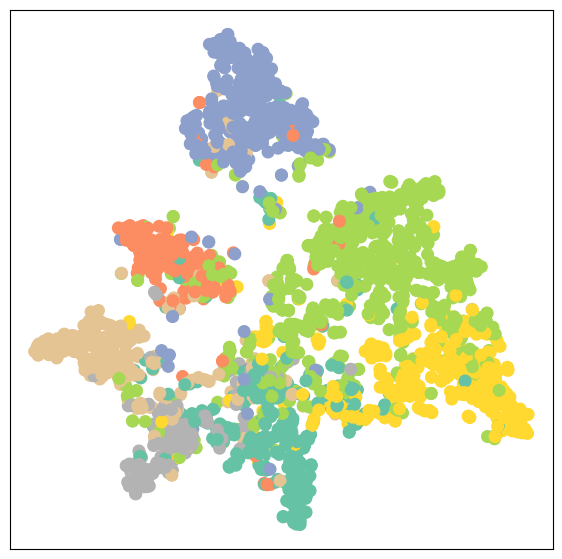

In [ ]:
_, embeddings = infer(model, data)
visualize_2d_embeddings_tsne(embeddings, data.y)

<a name='1.3'></a>
## 2️⃣ Link Prediction

### 🍿 MovieLens

We are going to use the [MovieLens dataset](https://grouplens.org/datasets/movielens/) collected by the GroupLens research group.
This dataset describes ratings and tagging activity from MovieLens.
- The dataset contains approximately **100k ratings** across **more than 9k movies** from **more than 600 users**.
- Nodes = movies, users
- Edges = whether a user has rated a specific movie

The link prediction task then tries to predict missing ratings, and can, for example, be used to recommend users new movies.

#### Data

##### Heterogeneous Graph

The dataset is composed of a set of **`*.csv` files**. First, we download these files to an arbitrary folder (in this case, the current directory).

In [ ]:
url = 'https://files.grouplens.org/datasets/movielens/ml-latest-small.zip'
extract_zip(download_url(url, '.'), '.')

movies_path = './ml-latest-small/movies.csv'
ratings_path = './ml-latest-small/ratings.csv'

Using existing file ml-latest-small.zip
Extracting ./ml-latest-small.zip


Let's take a look at the data.

In [ ]:
print('movies.csv:')
print('===========')
print(pd.read_csv(movies_path)[["movieId", "genres"]].head())
print()
print('ratings.csv:')
print('============')
print(pd.read_csv(ratings_path)[["userId", "movieId"]].head())

movies.csv:
   movieId                                       genres
0        1  Adventure|Animation|Children|Comedy|Fantasy
1        2                   Adventure|Children|Fantasy
2        3                               Comedy|Romance
3        4                         Comedy|Drama|Romance
4        5                                       Comedy

ratings.csv:
   userId  movieId
0       1        1
1       1        3
2       1        6
3       1       47
4       1       50


We can make use of the `genres` column to define a **feature representation for movies**.

In [ ]:
# Load the entire movie data frame into memory
movies_df = pd.read_csv(movies_path, index_col='movieId')

# Split genres and convert into indicator variables
genres = movies_df['genres'].str.get_dummies('|')
print(genres[["Action", "Adventure", "Drama", "Horror"]].head())

# Use genres as movie input features
movie_feat = torch.from_numpy(genres.values).to(torch.float)
assert movie_feat.size() == (9742, 20)  # 20 genres in total

         Action  Adventure  Drama  Horror
movieId                                  
1             0          1      0       0
2             0          1      0       0
3             0          0      0       0
4             0          0      1       0
5             0          0      0       0


We have to define the **connectivity** between users and movies.

In [ ]:
# Load the entire ratings data frame into memory
ratings_df = pd.read_csv(ratings_path)

# Create a mapping from unique user indices to range [0, num_user_nodes)
unique_user_id = ratings_df['userId'].unique()
unique_user_id = pd.DataFrame(data={
    'userId': unique_user_id,
    'mappedID': pd.RangeIndex(len(unique_user_id)),
})
print("Mapping of user IDs to consecutive values:")
print("==========================================")
print(unique_user_id.head())
print()

# Create a mapping from unique movie indices to range [0, num_movie_nodes)
unique_movie_id = pd.DataFrame(data={
    'movieId': movies_df.index,
    'mappedID': pd.RangeIndex(len(movies_df)),
})
print("Mapping of movie IDs to consecutive values:")
print("===========================================")
print(unique_movie_id.head())
print()

# Perform merge to obtain the edges from users and movies
ratings_user_id = pd.merge(ratings_df['userId'], unique_user_id,
                            left_on='userId', right_on='userId', how='left')
ratings_user_id = torch.from_numpy(ratings_user_id['mappedID'].values)
ratings_movie_id = pd.merge(ratings_df['movieId'], unique_movie_id,
                            left_on='movieId', right_on='movieId', how='left')
ratings_movie_id = torch.from_numpy(ratings_movie_id['mappedID'].values)

# With this, we are ready to construct our `edge_index` in COO format
edge_index_user_to_movie = torch.stack([ratings_user_id, ratings_movie_id], dim=0)
assert edge_index_user_to_movie.size() == (2, 100836)

print("Final edge indices pointing from users to movies:")
print("=================================================")
print(edge_index_user_to_movie)

Mapping of user IDs to consecutive values:
   userId  mappedID
0       1         0
1       2         1
2       3         2
3       4         3
4       5         4

Mapping of movie IDs to consecutive values:
   movieId  mappedID
0        1         0
1        2         1
2        3         2
3        4         3
4        5         4

Final edge indices pointing from users to movies:
tensor([[   0,    0,    0,  ...,  609,  609,  609],
        [   0,    2,    5,  ..., 9462, 9463, 9503]])


With this, we are ready to initialize our **heterogeneous graph** (`HeteroData` object).

We also add **reverse edges** to allow a GNN model to use both directions of the edge for message passing.

In [ ]:
data = HeteroData()

# Save node indices
data["user"].node_id = torch.arange(len(unique_user_id))
data["movie"].node_id = torch.arange(len(movies_df))

# Add the node features and edge indices
data["movie"].x = movie_feat
data["user", "rates", "movie"].edge_index = edge_index_user_to_movie

# We also need to make sure to add the reverse edges from movies to users
# in order to let a GNN be able to pass messages in both directions.
data = T.ToUndirected()(data)

print(data)

assert data.node_types == ["user", "movie"]
assert data.edge_types == [("user", "rates", "movie"),
                           ("movie", "rev_rates", "user")]
assert data["user"].num_nodes == 610
assert data["user"].num_features == 0
assert data["movie"].num_nodes == 9742
assert data["movie"].num_features == 20
assert data["user", "rates", "movie"].num_edges == 100836
assert data["movie", "rev_rates", "user"].num_edges == 100836

HeteroData(
  user={ node_id=[610] },
  movie={
    node_id=[9742],
    x=[9742, 20],
  },
  (user, rates, movie)={ edge_index=[2, 100836] },
  (movie, rev_rates, user)={ edge_index=[2, 100836] }
)


##### Train-Val-Test Split

We have to divide the ratings of users into training, validation, and test sets.
- We must ensure **no information leakage**.
  - The training set must not include any edges that appear in the validation or test sets.
  - The validation set must not include edges from the test set.
- **Not all training edges are used for supervision.** Some training edges are kept out of the message-passing graph and are instead used as ground-truth targets.
- Real-world graphs are highly sparse—most possible connections between nodes do *not* exist. To train a model that can distinguish between actual and non-existent edges, we introduce **negative samples**: randomly selected node pairs that are not connected in the graph.
  - These negative edges act as counterexamples during training.
  - The model learns to give high scores to real edges and low scores to negative ones.
  - Without negative sampling, the model would have no incentive to distinguish between connected and disconnected node pairs.

For this, we make use of the [`transforms.RandomLinkSplit`](https://pytorch-geometric.readthedocs.io/en/latest/modules/transforms.html#torch_geometric.transforms.RandomLinkSplit) transformation from PyG.


In [ ]:
# - We first split the set of edges into training (80%), validation (10%),
#   and testing edges (10%)
# - Across the training edges, we use 70% of edges for message passing,
#   and 30% of edges for supervision
# - We further want to generate negative edges for evaluation with a ratio of 2:1.
#   Negative edges during training will be generated on-the-fly, so we don't want to
#   add them to the graph right away
transform = T.RandomLinkSplit(
    num_val=0.1,  # ratio of edges to include in the validation set
    num_test=0.1,  # ratio of edges to include in the test set
    disjoint_train_ratio=0.3,  # ratio of edges used as ground-truth labels for supervision during training
    neg_sampling_ratio=2.0,  # ratio of sampled negative edges to the number of positive edges
    add_negative_train_samples=False,  # whether to pre-generate negative samples for training during the split, or leave the task to the training loop
    edge_types=("user", "rates", "movie"),
    rev_edge_types=("movie", "rev_rates", "user"),
)

train_data, val_data, test_data = transform(data)
print("Training data:")
print("==============")
print(train_data)
print()
print("Validation data:")
print("================")
print(val_data)

# Training data
# 80% of the total 100.836 edges = 80.670
# - Positive training edges used for message passing (70% of 80.670)
assert train_data["user", "rates", "movie"].num_edges == 56469
assert train_data["movie", "rev_rates", "user"].num_edges == 56469
# - Positive training edges used for supervision (30% of 80.670)
assert train_data["user", "rates", "movie"].edge_label_index.size(1) == 24201
# - No negative edges are added before training
#   - Edge labels are binary: 1 = positive (real) edge; 0 = negative (sampled) edge
#   - So, all training labels must be positive edges (i.e., label = 1)
assert train_data["user", "rates", "movie"].edge_label.min() == 1
assert train_data["user", "rates", "movie"].edge_label.max() == 1

# Validation data
# - The edges (not the label targets) used for message passing during validation
# - They include the same used for training, but treatead all as connectivity to
#   predict new labels
assert val_data["user", "rates", "movie"].num_edges == 80670
assert val_data["movie", "rev_rates", "user"].num_edges == 80670
# - Edge labels for evaluation
#   - 10% of the total 100.836 edges = 10.083
#   - 10.083 positive + 10.083 x 2 negative
assert val_data["user", "rates", "movie"].edge_label_index.size(1) == 30249
# - Negative edges with ratio 2:1
#   - 10.083 positive labels (1), 20.166 negative labels (0)
assert val_data["user", "rates", "movie"].edge_label.long().bincount().tolist() == [20166, 10083]

Training data:
HeteroData(
  user={ node_id=[610] },
  movie={
    node_id=[9742],
    x=[9742, 20],
  },
  (user, rates, movie)={
    edge_index=[2, 56469],
    edge_label=[24201],
    edge_label_index=[2, 24201],
  },
  (movie, rev_rates, user)={ edge_index=[2, 56469] }
)

Validation data:
HeteroData(
  user={ node_id=[610] },
  movie={
    node_id=[9742],
    x=[9742, 20],
  },
  (user, rates, movie)={
    edge_index=[2, 80670],
    edge_label=[30249],
    edge_label_index=[2, 30249],
  },
  (movie, rev_rates, user)={ edge_index=[2, 80670] }
)


##### Mini-batching

⚔️ When working with **large graphs**, it is often impossible to fit the entire graph and all of its computations into GPU memory. This is where **mini-batching** comes in.

In traditional supervised learning (e.g., image or document classification), mini-batching means processing a subset of the training examples at a time, instead of the entire dataset.

In **link prediction with GNNs**, each training example is a **pair of nodes (a link)**. So, a mini-batch consists of a **subset of links** we want to predict.

However, GNNs need more than just the edge pairs—they also require the **neighborhood structure** around each node to perform message passing.

This leads to the need for:
- **Sampling node neighborhoods** around each endpoint of the link.
- **Building subgraphs** from these sampled neighborhoods.

This process is handled automatically by PyG's [`LinkNeighborLoader`](https://pytorch-geometric.readthedocs.io/en/latest/modules/loader.html#torch_geometric.loader.LinkNeighborLoader).

Zooming out, this approach allows the GNN to learn from **local graph structure** around the links without having to operate on the entire graph at once.

🌱 The **"seed edges"** are the target edges that you want the model to predict in a given batch. They serve as starting points for sampling neighborhoods. Specifically, from each endpoint of a seed edge, the loader samples neighbors over multiple hops to form a local subgraph.

In [ ]:
# Define seed edges
edge_label_index = train_data["user", "rates", "movie"].edge_label_index
edge_label = train_data["user", "rates", "movie"].edge_label

# - In the first hop, we sample at most 20 neighbors
# - In the second hop, we sample at most 10 neighbors
# - In addition, during training, we want to sample negative edges on-the-fly with
#   a ratio of 2:1
train_loader = LinkNeighborLoader(
    data=train_data,  # graph object
    num_neighbors=[20,10],  # number of neighbors to sample for each node in each iteration
    neg_sampling_ratio=2.0,  # ratio of sampled negative edges to the number of positive edges
    edge_label_index=(("user", "rates", "movie"), edge_label_index),  # edge indices for which neighbors are sampled to create mini-batches
    edge_label=edge_label,  # labels of edge indices for which neighbors are sampled
    batch_size=128, # how many edges per batch to load
    shuffle=True, # the data will be reshuffled at every epoch
)

# Inspect a sample
sampled_data = next(iter(train_loader))

print("Sampled mini-batch:")
print("===================")
print(sampled_data)

# For every batch, 128 positive edges, 256 negative edges
assert sampled_data["user", "rates", "movie"].edge_label_index.size(1) == 3 * 128

# Edge labels in the batch must be binary
# 1 = positive (real) edge; 0 = negative (sampled) edge
assert sampled_data["user", "rates", "movie"].edge_label.min() == 0
assert sampled_data["user", "rates", "movie"].edge_label.max() == 1

Sampled mini-batch:
HeteroData(
  user={
    node_id=[609],
    n_id=[609],
  },
  movie={
    node_id=[2782],
    x=[2782, 20],
    n_id=[2782],
  },
  (user, rates, movie)={
    edge_index=[2, 17329],
    edge_label=[384],
    edge_label_index=[2, 384],
    e_id=[17329],
    input_id=[128],
  },
  (movie, rev_rates, user)={
    edge_index=[2, 7621],
    e_id=[7621],
  }
)


/usr/local/lib/python3.11/dist-packages/torch_geometric/sampler/neighbor_sampler.py:61: UserWarning: Using 'NeighborSampler' without a 'pyg-lib' installation is deprecated and will be removed soon. Please install 'pyg-lib' for accelerated neighborhood sampling
  warnings.warn(f"Using '{self.__class__.__name__}' without a "


#### SAGE Training and Evaluation

The GNN is responsible for learning enriched node representations from the surrounding subgraphs, which can be then used to derive edge-level predictions.
- For defining our GNN, we make use of [`nn.SAGEConv`](https://pytorch-geometric.readthedocs.io/en/latest/modules/nn.html#torch_geometric.nn.conv.SAGEConv) and the [`nn.to_hetero()`](https://pytorch-geometric.readthedocs.io/en/latest/modules/nn.html#torch_geometric.nn.to_hetero_transformer.to_hetero) function, which transforms a GNN defined on homogeneous graphs to be applied on **heterogeneous** ones.
- In addition, we define a **final link-level classifier**, which simply takes both node embeddings of the link we are trying to predict, and applies a **dot-product** on them.
- As users do not have any node-level information, we choose to **learn their features** jointly via a `torch.nn.Embedding` layer. In order to improve the expressiveness of movie features, we do the same for movie nodes, and simply add their shallow embeddings to the pre-defined genre features.

In [ ]:
# A 2-layer GNN computation graph, with a single ReLU non-linearity in-between
class GNN(torch.nn.Module):
    def __init__(self, hidden_channels):
        super().__init__()

        self.conv1 = SAGEConv(hidden_channels, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, hidden_channels)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        return x

# Our final classifier applies the dot-product between source and destination
# node embeddings to derive edge-level prediction
class Classifier(torch.nn.Module):
    def forward(self, x_user, x_movie, edge_label_index):
        edge_feat_user = x_user[edge_label_index[0]]
        edge_feat_movie = x_movie[edge_label_index[1]]
        return (edge_feat_user * edge_feat_movie).sum(dim=-1)

# The full model
class Model(torch.nn.Module):
    def __init__(self, hidden_channels):
        super().__init__()
        # Since the dataset does not come with rich features, we also learn two
        # embedding matrices for users and movies
        self.movie_lin = torch.nn.Linear(20, hidden_channels)
        self.user_emb = torch.nn.Embedding(data["user"].num_nodes, hidden_channels)
        self.movie_emb = torch.nn.Embedding(data["movie"].num_nodes, hidden_channels)
        # Instantiate homogeneous GNN
        self.gnn = GNN(hidden_channels)
        # Convert GNN model into a heterogeneous variant
        self.gnn = to_hetero(self.gnn, metadata=data.metadata())
        # Add the classification head
        self.classifier = Classifier()

    def forward(self, data: HeteroData):
        x_dict = {
          "user": self.user_emb(data["user"].node_id),
          "movie": self.movie_lin(data["movie"].x) + self.movie_emb(data["movie"].node_id),
        }

        # `x_dict` holds feature matrices of all node types
        # `edge_index_dict` holds all edge indices of all edge types
        x_dict = self.gnn(x_dict, data.edge_index_dict)

        pred = self.classifier(
            x_dict["user"],
            x_dict["movie"],
            data["user", "rates", "movie"].edge_label_index,
        )

        return pred

In [ ]:
model = Model(hidden_channels=64)
model = HeteroGNNWrapper(model)
print(model.model)

Model(
  (movie_lin): Linear(in_features=20, out_features=64, bias=True)
  (user_emb): Embedding(610, 64)
  (movie_emb): Embedding(9742, 64)
  (gnn): GraphModule(
    (conv1): ModuleDict(
      (user__rates__movie): SAGEConv(64, 64, aggr=mean)
      (movie__rev_rates__user): SAGEConv(64, 64, aggr=mean)
    )
    (conv2): ModuleDict(
      (user__rates__movie): SAGEConv(64, 64, aggr=mean)
      (movie__rev_rates__user): SAGEConv(64, 64, aggr=mean)
    )
  )
  (classifier): Classifier()
)


In [ ]:
limit_output_height()

criterion = F.binary_cross_entropy_with_logits
optimizer = torch.optim.Adam(model.model.parameters(), lr=0.001)

config = TrainingConfig(
    epochs=6,
    eval_validation=False,
    select_best_model_on_validation=False,
    make_video=False,
    print_every_epochs=1,
    loss_mask = None
)

model, _ = train(
    model_wrapper=model,
    data=data,
    label_field=("user", "rates", "movie"),
    label_field_nested="edge_label",
    criterion=criterion,
    optimizer=optimizer,
    config=config,
    train_loader=train_loader
)

<IPython.core.display.Javascript object>

Training with DataLoader: 190 batches per epoch


Epoch: 001, Loss: 0.7144


Epoch: 002, Loss: 0.6849


Epoch: 003, Loss: 0.6607


Epoch: 004, Loss: 0.6311


Epoch: 005, Loss: 0.6119


Epoch: 006, Loss: 0.6010


After training, we evaluate our model on **useen data** coming from the validation set.
- For this, we define a new `LinkNeighborLoader` (which now iterates over the edges in the validation set), obtain the predictions on validation edges by running the model, and finally evaluate the performance of the model by computing the **AUC score** over the set of predictions and their corresponding ground-truth edges (including both positive and negative edges).

**Why the AUC score?**
- After training our model, we want to understand how well it can generalize to unseen connections — in this case, edges from the validation set. These edges include both real ones (user-movie pairs that actually exist in the graph) and fake ones (randomly generated negative edges that do not exist). **The model assigns a score to each of these edges, indicating how likely it believes the edge is real.**
- To evaluate the model's performance, we use the AUC score, which stands for Area Under the ROC Curve. This metric is especially useful in link prediction because **it tells us how well the model ranks real edges above fake ones**. In other words, it measures the probability that a randomly chosen true edge will receive a higher score than a randomly chosen false one. This is a good fit for our task because we don’t want to just make a hard yes-or-no prediction for each edge — we care about how confidently and consistently the model prioritizes true edges over false ones.

In [ ]:
# Define the validation seed edges:
edge_label_index = val_data["user", "rates", "movie"].edge_label_index
edge_label = val_data["user", "rates", "movie"].edge_label

val_loader = LinkNeighborLoader(
    data=val_data,
    num_neighbors=[20, 10],
    edge_label_index=(("user", "rates", "movie"), edge_label_index),
    edge_label=edge_label,
    batch_size=3 * 128,
    shuffle=False,
)

sampled_data = next(iter(val_loader))

print("Sampled mini-batch:")
print("===================")
print(sampled_data)

assert sampled_data["user", "rates", "movie"].edge_label_index.size(1) == 3 * 128
assert sampled_data["user", "rates", "movie"].edge_label.min() >= 0
assert sampled_data["user", "rates", "movie"].edge_label.max() <= 1

Sampled mini-batch:
HeteroData(
  user={
    node_id=[607],
    n_id=[607],
  },
  movie={
    node_id=[2662],
    x=[2662, 20],
    n_id=[2662],
  },
  (user, rates, movie)={
    edge_index=[2, 18379],
    edge_label=[384],
    edge_label_index=[2, 384],
    e_id=[18379],
    input_id=[384],
  },
  (movie, rev_rates, user)={
    edge_index=[2, 7617],
    e_id=[7617],
  }
)


In [ ]:
from sklearn.metrics import roc_auc_score

preds = []
ground_truths = []
for sampled_data in tqdm.tqdm(val_loader):
    with torch.no_grad():
        sampled_data = sampled_data.to("cuda")
        preds.append(model.forward(sampled_data)[0])
        ground_truths.append(sampled_data["user", "rates", "movie"].edge_label)

pred = torch.cat(preds, dim=0).cpu().numpy()
ground_truth = torch.cat(ground_truths, dim=0).cpu().numpy()
auc = roc_auc_score(ground_truth, pred)
print()
print(f"Validation AUC: {auc:.4f}")

100%|██████████| 79/79 [00:03<00:00, 25.09it/s]


Validation AUC: 0.6964


<a name='1.4'></a>
## 3️⃣ Graph Prediction

### ⚛️ MUTAG

In this section, we explore how GNNs can be applied to the task of **graph classification**.

Graph classification involves assigning labels to entire graphs—rather than individual nodes—based on their structural and/or semantic characteristics, using a **dataset of graphs**.

Our goal is to learn meaningful graph-level embeddings that enable the graphs to be linearly separable for the specific classification task.

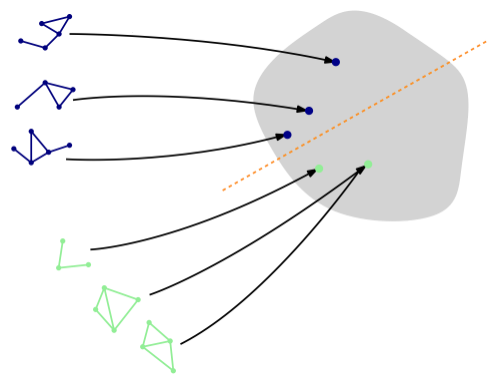

#### Data

A prevalent graph classification task is **molecular property prediction**, where molecules are modeled as graphs.
- In this representation, atoms (e.g., carbon, nitrogen, oxygen) correspond to nodes, and chemical bonds correspond to edges.
- The objective is to predict properties of entire molecules—such as their potential to inhibit HIV replication or their mutagenic effects—based on their structural and chemical characteristics.

The TU Dortmund University has collected a wide range of different graph classification datasets, known as the [**TUDatasets**](https://chrsmrrs.github.io/datasets/), which are also accessible via [`torch_geometric.datasets.TUDataset`](https://pytorch-geometric.readthedocs.io/en/latest/modules/datasets.html#torch_geometric.datasets.TUDataset) in PyG.

One of the most widely used dataset in this collection is **MUTAG**.
- It comprises **188 molecules**.
- The goal is to classify each molecule based on whether it has been found to cause genetic mutations in a specific type of bacteria—the **Salmonella typhimurium**.
- So, each molecule is annotated with a binary label following the results of laboratory tests, where a value of 1 denotes mutagenicity (i.e., the compound can cause genetic mutations), while 0 indicates non-mutagenicity.

**Why is this task important?**
- The bacterium Salmonella typhimurium is used in a well-known biological test called the **Ames test**.
- While not perfect, results from the Ames test **correlate reasonably well with the potential of chemicals to be carcinogenic (cancer-causing) in humans**. So it's often used to flag dangerous substances early.
- **Predicting mutagenicity on this dataset simulates what scientists already do in labs, but faster and at larger scale.**

In [ ]:
dataset = TUDataset(root='data/TUDataset', name='MUTAG')
print_dataset_stats(dataset)

Dataset: TUDataset
Number of graphs: 188
Number of features: 7
Number of classes: 2



Processing...
Done!


In [ ]:
data = dataset[0]  # Get the first graph object
print_graph_stats(data)

Data(edge_index=[2, 38], x=[17, 7], edge_attr=[38, 4], y=[1])
Number of nodes: 17
Number of edges: 38
Average node degree: 2.24
No training mask available.
Has isolated nodes: False
Has self-loops: False
Is undirected: True



By inspecting the first graph object of the dataset, we can see that it comes with **17 nodes (with 7-dimensional feature vectors)** and **38 edges**, with an average node degree of 2.24.
It also comes with exactly **one graph label** (`y=[1]`), and, in addition to previous datasets, **4-dimensional edge features** (`edge_attr=[38, 4]`).
However, for the sake of simplicity, we will not make use of those.

##### Train-Test Split

PyG provides some useful utilities for working with graph datasets, *e.g.*, we can shuffle the dataset and **use the first 150 graphs as training graphs, while using the remaining ones for testing**.

In [ ]:
dataset = dataset.shuffle()

train_dataset = dataset[:150]
test_dataset = dataset[150:]

print(f'Number of training graphs: {len(train_dataset)}')
print(f'Number of test graphs: {len(test_dataset)}')

Number of training graphs: 150
Number of test graphs: 38


##### Mini-batching

Since graphs in graph classification datasets are usually small, a good idea is to **batch the graphs** before inputting them into a GNN to guarantee full GPU utilization.

To achieve parallelization across a number of examples, PyG **stacks adjacency matrices in a diagonal fashion** (creating a giant graph that holds multiple isolated subgraphs). **Node and target features are simply concatenated in the node dimension**.

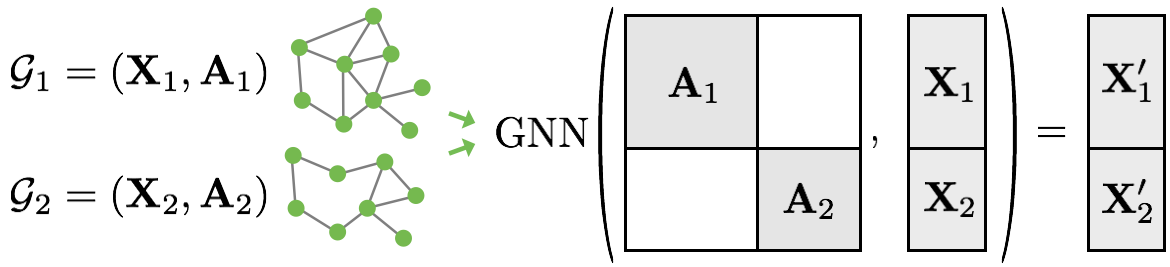

This procedure has one crucial advantage:

1. **No need for architecture intervention.** GNN operators that rely on a message passing scheme do not need to be modified since *messages are not exchanged between two nodes that belong to different graphs*.

PyG automatically takes care of **batching multiple graphs into a single giant graph** with the help of the [`torch_geometric.data.DataLoader`](https://pytorch-geometric.readthedocs.io/en/latest/modules/data.html#torch_geometric.data.DataLoader) class.

**🕵️ Under the Hood: How PyG Batches Graphs**

Are you curious about how this "diagonal stacking" is actually implemented in code?

While the image above shows **Adjacency Matrices** ($A$) to make the concept visually intuitive, PyG does not actually use dense matrices (which would be memory-heavy). Instead, it uses **sparse edge indices**.

Since we cannot physically "stack" coordinate lists diagonally, PyG performs a clever trick called **Index Shifting (or Offsetting)**.

---

**1. The Problem: Duplicate Indices**
Imagine you want to batch two separate graphs:
* **Graph A (3 nodes):** Nodes `0, 1, 2`.
* **Graph B (2 nodes):** Nodes `0, 1`.

If we simply concatenated their edge lists, the computer wouldn't know that Node `0` in Graph B is different from Node `0` in Graph A. They would merge into a mess.

---

**2. The Solution: Index Shifting**
To fix this, PyG treats the batch as one giant "Super Graph." It preserves the indices of the first graph but **renumbers** the nodes of subsequent graphs by adding an offset.

**The Logic:**
$$\text{New Index} = \text{Original Index} + \text{Total Nodes in Previous Graphs}$$

---

**3. A Concrete Example**
Let's see what happens to the data tensors when we batch Graph A (3 nodes) and Graph B (2 nodes):

| Component | Transformation Logic | Resulting Data Structure |
| :--- | :--- | :--- |
| **Node Features ($X$)** | **Stacked Vertically** <br> Just like standard data batches. | `Shape: [5, num_features]` |
| **Edge Indices** | **Concatenated with Offset** <br> Graph A edges stay `[0, 1]`. <br> Graph B edges `[0, 1]` get shifted by **+3** to become `[3, 4]`. | `[[0, 1, 3, 4], ...]` |
| **Batch Vector** | **Created New** <br> Maps every node to its graph ID. | `[0, 0, 0, 1, 1]` |

---

**Key Takeaway:**
PyG allows us to process multiple graphs simultaneously without them interfering with each other by mathematically isolating their indices in a shared sparse tensor.

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

for step, data in enumerate(train_loader):
    print(f'Step {step + 1}:')
    print('=======')
    print(f'Number of graphs in the current batch: {data.num_graphs}')
    print(data)
    print()

Step 1:
Number of graphs in the current batch: 64
DataBatch(edge_index=[2, 2420], x=[1096, 7], edge_attr=[2420, 4], y=[64], batch=[1096], ptr=[65])

Step 2:
Number of graphs in the current batch: 64
DataBatch(edge_index=[2, 2624], x=[1190, 7], edge_attr=[2624, 4], y=[64], batch=[1190], ptr=[65])

Step 3:
Number of graphs in the current batch: 22
DataBatch(edge_index=[2, 900], x=[404, 7], edge_attr=[900, 4], y=[22], batch=[404], ptr=[23])



Here, we opt for a `batch_size` of 64, leading to 3 (randomly shuffled) mini-batches, containing all $2 \cdot 64+22 = 150$ graphs.

Furthermore, each `Batch` object is equipped with a **`batch` vector**, which maps each node to its respective graph in the batch:

$$
\textrm{batch} = [ 0, \ldots, 0, 1, \ldots, 1, 2, \ldots ]
$$

#### GCN Training and Evaluation

Training a GNN for graph classification usually follows a simple recipe:

1. Embed each node by performing multiple rounds of message passing
2. Aggregate node embeddings into a unified graph embedding (**readout layer**)
3. Train a final classifier on the graph embedding

There exists multiple **readout layers** in literature, but the most common one is to simply take the **average of node embeddings**:

$$
\mathbf{x}_{\mathcal{G}} = \frac{1}{|\mathcal{V}|} \sum_{v \in \mathcal{V}} \mathcal{x}^{(L)}_v
$$

PyG provides this functionality via [`torch_geometric.nn.global_mean_pool`](https://pytorch-geometric.readthedocs.io/en/latest/modules/nn.html#torch_geometric.nn.glob.global_mean_pool), which takes in the node embeddings of all nodes in the mini-batch and the assignment vector `batch` to compute a graph embedding of size `[batch_size, hidden_channels]` for each graph in the batch.

In [ ]:
class GCN(torch.nn.Module):
    def __init__(self, hidden_channels):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(dataset.num_node_features, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        self.lin = Linear(hidden_channels, dataset.num_classes)

    def forward(self, x, edge_index, batch):
        # 1. Obtain node embeddings
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()
        x = self.conv3(x, edge_index)

        # 2. Readout layer
        x = global_mean_pool(x, batch)  # [batch_size, hidden_channels]

        # 3. Apply a final classifier
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin(x)

        return x

In [ ]:
model = GCN(hidden_channels=64)
model = GNNGraphWrapper(model)
print(model.model)

GCN(
  (conv1): GCNConv(7, 64)
  (conv2): GCNConv(64, 64)
  (conv3): GCNConv(64, 64)
  (lin): Linear(in_features=64, out_features=2, bias=True)
)


In [ ]:
limit_output_height()

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.model.parameters(), lr=0.01)

config = TrainingConfig(
    epochs=200,
    eval_validation=False,
    select_best_model_on_validation=False,
    make_video=False,
    print_every_epochs=10,
    loss_mask = None
)

model, _ = train(
    model_wrapper=model,
    data=data,
    label_field="y",
    criterion=criterion,
    optimizer=optimizer,
    config=config,
    train_loader=train_loader
)

<IPython.core.display.Javascript object>

Training with DataLoader: 3 batches per epoch


Epoch: 010, Loss: 0.5820


Epoch: 020, Loss: 0.5400


Epoch: 030, Loss: 0.5313


...

Epoch: 160, Loss: 0.4598


Epoch: 170, Loss: 0.4533


Epoch: 180, Loss: 0.5006


Epoch: 190, Loss: 0.4522


Epoch: 200, Loss: 0.4595


In [ ]:
model.eval()

correct = 0
for sampled_data in tqdm.tqdm(test_loader):
  sampled_data.to("cuda")
  out, _ = model.forward(sampled_data)
  pred = out.argmax(dim=1)
  correct += int((pred == sampled_data.y).sum())
acc = correct / len(test_dataset)
print(f'\nAccuracy: {acc:.4f}')

100%|██████████| 1/1 [00:00<00:00, 75.23it/s]


Accuracy: 0.8158


<a name='2'></a>
# **Hands-on Knowledge Graph Embedding**

In the first part of the lab, we explored GNNs — powerful models that learn from graph-structured data by propagating information across nodes and edges.
Now, we shift our focus to a related but distinct domain: **Knowledge Graph Embedding (KGE)**.

**🌐 A KG is a special type of graph**
- A KG represents structured information as a collection of **factual triples**: `(head entity, relation, tail entity)` — for example, `(Paris, capital_of, France)`.
- Unlike general graphs used in GNNs, KGs:
  - Are often **sparse and incomplete**
  - **Do not usually come with node features**
  - Emphasize **semantic relationships** (multi-relational linkage) over topological patterns

**🎯 KGE Goal**

KGE is a method of representing entities and relationships within a KG as low-dimensional, continuous vectors (embeddings).

**💡 KGE Motivation**

The core motivation behind KGE is to transform complex, high-dimensional, discrete graph data into a continuous vector form that is more amenable to machine learning tasks like link prediction, knowledge completion, and graph-based recommendations.

![KGE](https://miro.medium.com/v2/resize:fit:1400/0*NgeOIx8UMnAbUDEF.png)

---
</br>

**📚 How does KGE work?**

> Unlike GNNs, which operate on node-level message passing, KGE models **directly learn from triple patterns** using supervised or self-supervised signals.

- KGE techniques typically rely on learning embeddings by **distinguishing between positive (existing) and negative (non-existing) triples** in the KG.
- The key idea is to:
  1. **Generating negative samples.** To create negative examples, we often rely on the **Local Closed World Assumption (LCWA)**, which assumes that the KG is locally complete. In this context, any missing facts in the graph are treated as false. Thus, negative samples are generated by randomly replacing parts of the existing triples to form "non-existing" facts that are unlikely to be true.
  2. **Train a model to assign higher scores to positive triples and lower scores to negative triples**.

<a name='2.1'></a>
## ⚙️ Set Up Kernel and Required Dependencies

Check that the Runtime type is `Python 3` with a `GPU`-based hardware accelerator.

Go to "Runtime" $→$ "Change runtime type".

In [ ]:
!pip install pykeen
!pip install sentence_transformers

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 730.3/730.3 kB 27.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 386.6/386.6 kB 37.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 122.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 94.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 63.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
# Tensor computation and deep learning
import torch

# Numerical computations
import numpy as np

# Tabular data
import pandas as pd

# Read and write JSON files, data interchange
import json

# Create and manupulate graph structures
import networkx as nx

# Generate dense vector representations of text
from sentence_transformers import SentenceTransformer

# KGE
from pykeen import predict
from pykeen.triples import TriplesFactory
from pykeen.pipeline import pipeline
from pykeen.nn.init import PretrainedInitializer

# Clustering, evaluation metrics, linear models, and preprocessing
from sklearn.cluster import *
from sklearn.metrics import *
from sklearn.linear_model import *
from sklearn.preprocessing import *
from sklearn.manifold import TSNE

# Data iteration
from itertools import islice

# Data visualization
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure

<a name='2.2'></a>
## 🧠 KG Preparation


**⚠️ Note:** initially, the dataset contains positive triples only; negative sampling is applied during training.

In [ ]:
!wget https://nlp.stanford.edu/projects/myasu/QAGNN/data_preprocessed_biomed.zip
!unzip /content/data_preprocessed_biomed.zip

--2025-05-28 09:28:37--  https://nlp.stanford.edu/projects/myasu/QAGNN/data_preprocessed_biomed.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 102521846 (98M) [application/zip]
Saving to: ‘data_preprocessed_biomed.zip’

data_preprocessed_b 100%[===================>]  97.77M  53.4MB/s    in 1.8s    

2025-05-28 09:28:39 (53.4 MB/s) - ‘data_preprocessed_biomed.zip’ saved [102521846/102521846]

Archive:  /content/data_preprocessed_biomed.zip
   creating: data_preprocessed_biomed/
   creating: data_preprocessed_biomed/ddb/
  inflating: data_preprocessed_biomed/ddb/ddb_names.json  
  inflating: data_preprocessed_biomed/ddb/ddb.graph  
  inflating: data_preprocessed_biomed/ddb/ddb_to_umls_cui.txt  
  inflating: data_preprocessed_biomed/ddb/ent_emb.npy  
  inflating: data_preprocessed_biomed/ddb/ddb_relas.json  
  inflating: data_preproc

In [ ]:
# Convert edge info from json to dict
with open('/content/data_preprocessed_biomed/ddb/ddb_relas.json') as json_file:
	edges_dict = json.load(json_file)
print('number of edges: ' + str(len(edges_dict)))

# Convert node info from json to dict
with open('/content/data_preprocessed_biomed/ddb/ddb_names.json') as json_file:
	nodes_dict = json.load(json_file)
nodes_dict = {value[0]:key for key, value in nodes_dict.items()}
print('number of nodes: ' + str(len(nodes_dict)))

number of edges: 49974
number of nodes: 9958


In [ ]:
for key, value in islice(edges_dict.items(), 10):
    print(f"{key}: {value}")

0: ['3884', '1', '3']
1: ['7034', '1', '3']
2: ['7351', '1', '3']
3: ['7352', '1', '3']
4: ['7597', '1', '3']
5: ['9474', '1', '3']
6: ['9475', '1', '3']
7: ['9476', '1', '3']
8: ['10477', '1', '3']
9: ['10478', '1', '3']


In [ ]:
relas = [
    'belongs_to_the_category_of',
    'is_a_category',
    'may_cause',
    'is_a_subtype_of',
    'is_a_risk_factor_of',
    'is_associated_with',
    'may_contraindicate',
    'interacts_with',
    'belongs_to_the_drug_family_of',
    'belongs_to_drug_super-family',
    'is_a_vector_for',
    'may_be_allelic_with',
    'see_also',
    'is_an_ingradient_of',
    'may_treat'
]

relas_dict = {"0": 0, "1": 1, "2": 2, "3": 3, "4": 4, "6": 5, "10": 6, "12": 7, "16": 8, "17": 9, "18": 10,
              "20": 11, "26": 12, "30": 13, "233": 14}

In [ ]:
with open('triplets.txt', 'a') as triplets:

  for _, triplet in edges_dict.items():

    h_id = triplet[0]
    t_id = triplet[1]
    r_id = triplet[2]

    h_txt = nodes_dict[h_id]
    t_txt = nodes_dict[t_id]
    r_txt = relas[relas_dict[r_id]]

    triplets.write('\t'.join([h_txt, r_txt, t_txt]) + "\n")

In [ ]:
with open('triplets.txt', 'r') as triplets:
    for line in islice(triplets, 10):
        print(line.strip())

Tall R wave in V1	is_a_subtype_of	Electrocardiogram change
Osborne waves	is_a_subtype_of	Electrocardiogram change
Left QRS axis deviation	is_a_subtype_of	Electrocardiogram change
Left bundle branch block	is_a_subtype_of	Electrocardiogram change
Low voltage ECG	is_a_subtype_of	Electrocardiogram change
P mitrale	is_a_subtype_of	Electrocardiogram change
P pulmonale	is_a_subtype_of	Electrocardiogram change
P wave inversion	is_a_subtype_of	Electrocardiogram change
PR interval lengthened	is_a_subtype_of	Electrocardiogram change
PR interval shortening	is_a_subtype_of	Electrocardiogram change


<a name='2.3'></a>
## 🗺️ KGE with Random Entity Initialization

#### Train-Eval-Test Split

In [ ]:
# Split triplets in train and test set (80/20)
# Note: eval unlocks early stopping
tf = TriplesFactory.from_path('/content/triplets.txt')
train, eval, test = tf.split([.8, .1, .1])

INFO:pykeen.triples.splitting:done splitting triples to groups of sizes [30116, 4997, 4998]


#### TransE

In [ ]:
result = pipeline(
    training=train,
    validation=eval,
    testing=test,
    model='TransE',
    stopper='early',
    epochs=250
)
result.save_to_directory('stanford_kg_transe')

INFO:pykeen.pipeline.api:Using device: None
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()
INFO:pykeen.stoppers.early_stopping:Inferred checkpoint path for best model weights: /root/.data/pykeen/checkpoints/best-model-weights-87b4ec99-bc65-45ab-acf7-0647b53dd2cb.pt


Training epochs on cuda:0:   0%|          | 0/1000 [00:00<?, ?epoch/s]

Training batches on cuda:0:   0%|          | 0.00/157 [00:00<?, ?batch/s]

Training batches on cuda:0:   0%|          | 0.00/157 [00:00<?, ?batch/s]

Training batches on cuda:0:   0%|          | 0.00/157 [00:00<?, ?batch/s]

...

Training batches on cuda:0:   0%|          | 0.00/157 [00:00<?, ?batch/s]

Training batches on cuda:0:   0%|          | 0.00/157 [00:00<?, ?batch/s]

INFO:pykeen.evaluation.evaluator:Evaluation took 0.67s seconds
INFO:pykeen.stoppers.early_stopping:Stopping early at epoch 230. The best result 0.10196117670602362 occurred at epoch 210.
INFO:pykeen.stoppers.early_stopping:Re-loading weights from best epoch from /root/.data/pykeen/checkpoints/best-model-weights-87b4ec99-bc65-45ab-acf7-0647b53dd2cb.pt


Evaluating on cuda:0:   0%|          | 0.00/5.00k [00:00<?, ?triple/s]

INFO:pykeen.evaluation.evaluator:Evaluation took 0.88s seconds
INFO:pykeen.triples.triples_factory:Stored TriplesFactory(num_entities=9956, num_relations=15, create_inverse_triples=False, num_triples=39979, path="/content/triplets.txt") to file:///content/stanford_kg_transe/training_triples
INFO:pykeen.pipeline.api:Saved to directory: /content/stanford_kg_transe


#### Evaluation

KGE models are commonly evaluated using the link prediction task.

> Can the model infer positive missing triples that were not seen during training?

The evaluation is typically framed as a **ranking problem**.
- For each true triple in the test set (called a gold triple), we create a **ranking query** by corrupting it — the same way we did during training.
- The model **scores all candidate triples (one gold + many negatives)**, and we **rank them by plausibility**. A good model assigns a high score (low rank) to the true triple and lower scores (higher ranks) to the corrupted ones.

<img src="https://drive.google.com/uc?export=view&id=1ugMud2gBL4QKGlvK1PLa_eVh3kJYBGmj" alt="MNIST" width="480"/>

---

Common evaluation metrics.

- **Mean Rank (MR)**
  - *Description:* Average rank of the correct entity
  - *Boundary:* `[1, num_entities]`
  - *Interpretation:* The lower, the better

- **Mean Reciprocal Rank (MRR)**
  - *Description:* Average of the reciprocal ranks of the correct entity
  - *Equation:* $MRR = \frac{1}{N}\sum_{i=1}^{N}\frac{1}{rank_i}$
  - *Boundary:* `(0, 1]`
  - *Interpretation:* The higher, the better; i.e., higher MRR means the correct entity is ranked near the top more consistently

In [ ]:
mr = result.get_metric('mr') # out of 9958
mrr = result.get_metric('mrr')
print(' '.join([str(mr), str(mrr)]))

1023.234375 0.04491114616394043


👤 Qualitative tail prediction.

In [ ]:
predict.predict_target(
    model=result.model,
    head="Gastritis",
    relation="may_cause", #is_associated_with
    triples_factory=result.training)

TargetPredictions(df=      tail_id      score                               tail_label
3034     3034  -5.092019                                Gastritis
33         33  -6.334885                           Abdominal pain
6321     6321  -6.403574                        Peptic ulceration
6687     6687  -7.306073           Polymorphonuclear leukocytosis
5883     5883  -7.422531                          Oral ulceration
...       ...        ...                                      ...
9750     9750 -13.071028                           Wilson disease
2949     2949 -13.071299                        Fuhrmann syndrome
7430     7430 -13.151180     Rhizomelic chondrodysplasia punctata
8192     8192 -13.152193  Spondylometaphyseal dysplasia, X-linked
925       925 -13.278791                           Bruck syndrome

[9956 rows x 3 columns], factory=TriplesFactory(num_entities=9956, num_relations=15, create_inverse_triples=False, num_triples=39979, path="/content/triplets.txt"), target='tail', other_

<a name='2.4'></a>
## 🗺️ KGE with LM-Based Entity Initialization

In [ ]:
entity_labels = list(tf.entity_id_to_label.values())

model = SentenceTransformer("neuml/pubmedbert-base-embeddings-matryoshka")
embeddings = model.encode(entity_labels, convert_to_tensor=True, device="cuda")

dimensionality = 64

embeddings = embeddings[:, :dimensionality]
embeddings = embeddings.contiguous()

embeddings.shape

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/171 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/7.43k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/226k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/706k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

torch.Size([9956, 64])

In [ ]:
result_lm = pipeline(
    training=train,
    validation=eval,
    testing=test,
    model='TransE',
    stopper='early',
    epochs=250,
    model_kwargs=dict(
        embedding_dim=embeddings.shape[-1],
        entity_initializer=PretrainedInitializer(tensor=embeddings),
    ),
    device="cuda",
)
result_lm.save_to_directory('stanford_kg_transe_lm')

INFO:pykeen.pipeline.api:Using device: cuda
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()
INFO:pykeen.stoppers.early_stopping:Inferred checkpoint path for best model weights: /root/.data/pykeen/checkpoints/best-model-weights-5811e2e0-afcd-4fe3-8630-070218d4d4cd.pt


Training epochs on cuda:0:   0%|          | 0/250 [00:00<?, ?epoch/s]

Training batches on cuda:0:   0%|          | 0.00/157 [00:00<?, ?batch/s]

Training batches on cuda:0:   0%|          | 0.00/157 [00:00<?, ?batch/s]

Training batches on cuda:0:   0%|          | 0.00/157 [00:00<?, ?batch/s]

...

Training batches on cuda:0:   0%|          | 0.00/157 [00:00<?, ?batch/s]

Training batches on cuda:0:   0%|          | 0.00/157 [00:00<?, ?batch/s]

INFO:pykeen.evaluation.evaluator:Evaluation took 0.72s seconds
INFO:pykeen.stoppers.early_stopping:Stopping early at epoch 60. The best result 0.1822093255953572 occurred at epoch 40.
INFO:pykeen.stoppers.early_stopping:Re-loading weights from best epoch from /root/.data/pykeen/checkpoints/best-model-weights-5811e2e0-afcd-4fe3-8630-070218d4d4cd.pt


Evaluating on cuda:0:   0%|          | 0.00/5.00k [00:00<?, ?triple/s]

INFO:pykeen.evaluation.evaluator:Evaluation took 0.73s seconds
INFO:pykeen.triples.triples_factory:Stored TriplesFactory(num_entities=9956, num_relations=15, create_inverse_triples=False, num_triples=39979, path="/content/triplets.txt") to file:///content/stanford_kg_transe_lm/training_triples
INFO:pykeen.pipeline.api:Saved to directory: /content/stanford_kg_transe_lm


In [ ]:
mr = result_lm.get_metric('mr') # out of 9958
mrr = result_lm.get_metric('mrr')
print(' '.join([str(mr), str(mrr)]))

516.117919921875 0.07526460289955139


In [ ]:
predict.predict_target(
    model=result_lm.model,
    head="Gastritis",
    relation="may_cause", #is_associated_with
    triples_factory=result.training)

TargetPredictions(df=      tail_id      score                                         tail_label
3034     3034  -5.538150                                          Gastritis
6321     6321  -6.883857                                  Peptic ulceration
33         33  -7.413311                                     Abdominal pain
6130     6130  -7.998847                                       Pancreatitis
3341     3341  -8.121387                                           Headache
...       ...        ...                                                ...
163       163 -13.704235            Adrenal hypoplasia, X-linked congenital
3539     3539 -13.720947                    Human granulocytic ehrlichiosis
1681     1681 -13.756536              Congenital adrenal hyperplasia type 3
7080     7080 -13.829112  Pulmonary surfactant protein C deficiency (con...
810       810 -14.035215       Blastic plasmacytoid dendritic cell neoplasm

[9956 rows x 3 columns], factory=TriplesFactory(num_entities=9956,